# Abstraction

Entity matching (EM) tries to find same real-world entities from different data sources. In this notebook, we will try to build a POC for EM of HealthCare data.

This is small dataset, it contains many sheets. We try to process data into 2 datasets then we can compare data between 2 datasets together.
after that we try to process data and apply classification in our data. The steps would be:

**Step 1**: concatenate data and build 2 dataset **A** and **B**

**Step 2**: Apply Magellan into preprocess data

**Step 3**: Building a classification model

**Step 4**: Evaluate model

# Import library

In [26]:
# !pip install  torchtext==0.10.0  torch==1.9
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from itertools import permutations
import os 
import typing as tp

try:
  import msoffcrypto
  import py_entitymatching as em
except:
  !pip install msoffcrypto-tool
finally:
  import msoffcrypto

try:
    import py_entitymatching as em
except:
    !pip install setuptools wheel
    !pip install Cython
    !pip install git+https://github.com/anhaidgroup/py_stringsimjoin.git@master
    !pip install git+https://github.com/anhaidgroup/py_entitymatching.git@master
    !pip install fasttext-wheel
finally:
  import py_entitymatching as em

import sys
sys.path.append('/Users/tu/SourceCode/GRIT/deepmatcher')
sys.path.append('../')

import deepmatcher as dm

pd.options.display.max_columns = None

In [7]:
import src.utils.auto_config as config 

DIR_DUPLICATEFINDER: /Users/tu/SourceCode/GRIT/duplicate-finder/src


In [138]:
data_dir = '/Users/tu/SourceCode/notebooks/data/'

# Data Loading

In [11]:
decrypted_workbook = io.BytesIO()
with open(data_dir + "hcp-manz-sn.xlsx", 'rb') as file:
    office_file = msoffcrypto.OfficeFile(file)
    office_file.load_key(password=config.DATA_PASSWORD)
    office_file.decrypt(decrypted_workbook)

df_dict = {}
for sheet_name in pd.read_excel(decrypted_workbook, None).keys():
  df = pd.read_excel(decrypted_workbook, sheet_name=sheet_name)
  df_dict[sheet_name] = df

# Data Exploration and Understanding

### Building pair of datasets

'(360) Validation Check' sheet contains schema that is different with other sheets. We ignore it at the moment. The sheet '(1000) Contacts' has a lots of records we could assign it as first data set **A**, others sheets will be concatenate into dataset **B**. The sheets in dataset **B** have a specific columne "Unnamed: x", we need to normalize it before concatenating them together.

In [116]:
def build_data_pair(items_in_A: tp.List[ tp.Union[str, pd.DataFrame]], items_in_B: tp.List[ tp.Union[str, pd.DataFrame]]) -> tp.Tuple[pd.DataFrame]:
    def process_items(items:tp.Union[str, pd.DataFrame]) -> tp.List[pd.DataFrame]:
        item_dfs = []
        for item in items:
            if isinstance(item, str):
                item_df = pd.read_csv(item)
                item_dfs.append(item_df)
            elif isinstance(item, pd.DataFrame):
                item_dfs.append(item)
            else:
                raise Exception("Data type is not supported!")
            
        return item_dfs
    
    A_items = process_items(items_in_A)
    B_items = process_items(items_in_B)

    return (pd.concat(A_items), pd.concat(B_items))

In [117]:
A, B = build_data_pair(
    items_in_A=[df_dict['(1000) Contacts']], 
    items_in_B=[df_dict['(800) No SAP Number and Export '], df_dict['(340) US HCPs'], df_dict['(320) OUS HCPs'], df_dict['(20) France HCPs']]
)

A.head()

,Status,Contact Type,Prefix,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,State/Region,Country,National Physician ID,Unnamed: 14,State License #,License State (US),Title,Specialty,Focus Area,Taxonomy,Taxonomy Code,Payment Currency,Email Address,Primary Address,Mailing Address,Primary Organization,Primary Organization Type,Quickbase Record ID#
0,Active,HCP,NaN,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,NaN,NaN,NaN,NaN,NaN,India,NaN,NaN,NaN,NaN,NaN,Vascular Surgery (VS),NaN,NaN,NaN,USD,Gireesh.w@gmail.com,NaN,NaN,NaN,NaN,7676.0
1,Active,HCP,NaN,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,NaN,United States,1134357429,NaN,NaN,NaN,NaN,Diagnostic Radiology (R),NaN,NaN,NaN,USD,JMcGrath@KaleidaHealth.org,NaN,NaN,NaN,NaN,6617.0
2,Active,HCP,NaN,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,NaN,NaN,NaN,Santa Catarina,NaN,Brazil,NaN,NaN,29195,NaN,NaN,Interventional Cardiology (IC),NaN,NaN,NaN,BRL,andredallanora@hotmail.com,NaN,NaN,NaN,NaN,7683.0
3,Active,HCP,NaN,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,NaN,NaN,Latvia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EUR,helmutskidikas@gmail.com,NaN,NaN,NaN,NaN,742.0
4,Active,HCP,NaN,Christoph,Griessenauer,Christoph Griessenauer,Physician,Self,90183682,Christoph Griessenauer,NaN,NaN,Austria,NaN,NaN,NaN,NaN,NaN,Neurosurgery (NS),NaN,NaN,NaN,EUR,christoph.griessenauer@gmail.com,NaN,NaN,NaN,NaN,6995.0


# Preprocessing and Feature Engineering

<center><img src="images/preprocessing_flow.png" height = "600px"/></center>

Data will be filtered by blockers in Magenlla and return 2 datasets with smaller sizes. By using blockers, we try to ignore those records that obviously non-matching:
- The first step runs filter for **A** and **B** datasets and return a candidate **K**
- second step, we use candidate **K** to continue doing blocking 
- third setp and so on, we do the same secode step (recursively) but on different column condition
- the final output, we try to generate **A'** and **B'** that have the same column names with A and B but the size is smallers. 

In [118]:
def detect_high_missing_features(df: pd.DataFrame, missing_percentage_threshold: float = 30) -> tp.List[str]:
    """Identify features in dataframe that have a lots of missing values. 
    We use a percentage threshold to capture feature that has more than that and 
    list all of them. 

    Args:
        df (pd.DataFrame): input data as DataFrame
        missing_percentage_threshold (float, optional): threshold to identify a significant missing value feature. Defaults to 30.

    Returns:
        List: a list of significant missing value features
    """
    missing_percentage = df.isna().sum()/df.shape[0] * 100
    removed_missed_features = missing_percentage[missing_percentage > missing_percentage_threshold].index
    return removed_missed_features

### Normalize feature

In [119]:
A = A.rename(columns={'Unnamed: 14': "Unnamed"})
B = B.rename(columns={'Unnamed: 15': "Unnamed"})

### Missing data 

In [120]:
removed_features_for_A = detect_high_missing_features(A, missing_percentage_threshold=59.2)
removed_features_for_B = detect_high_missing_features(B, missing_percentage_threshold=59.2)
removed_features = set(removed_features_for_A) & set(removed_features_for_B)
A = A[[col for col in A.columns if col not in removed_features]]
B = B[[col for col in B.columns if col not in removed_features]]

### Process data 

In [121]:
A.head()

,Status,Contact Type,First Name,Last Name,Full Name,HCP Category,Payments Made To:,SAP Number,SAP Entity Name,State/Region/Province,Country,National Physician ID,Specialty,Payment Currency,Email Address,Quickbase Record ID#
0,Active,HCP,Gireesh Mukund,Warawdekar,Gireesh Mukund Warawdekar,Physician,NaN,NaN,NaN,NaN,India,NaN,Vascular Surgery (VS),USD,Gireesh.w@gmail.com,7676.0
1,Active,HCP,John,McGrath,John McGrath,Physician,Self,90358189,John R. McGrath,New York,United States,1134357429,Diagnostic Radiology (R),USD,JMcGrath@KaleidaHealth.org,6617.0
2,Active,HCP,Andre,Fernandes Dallanora,Andre Fernandes Dallanora,Physician,NaN,NaN,NaN,Santa Catarina,Brazil,NaN,Interventional Cardiology (IC),BRL,andredallanora@hotmail.com,7683.0
3,Active,HCP,Helmuts,Kidikas,Helmuts Kidikas,Physician,Self,90180723,Helmuts Kidikas,NaN,Latvia,NaN,NaN,EUR,helmutskidikas@gmail.com,742.0
4,Active,HCP,Christoph,Griessenauer,Christoph Griessenauer,Physician,Self,90183682,Christoph Griessenauer,NaN,Austria,NaN,Neurosurgery (NS),EUR,christoph.griessenauer@gmail.com,6995.0


In [122]:
def process_data(A, B, blocking_config: tp.Dict):
    # retrieve metadata for Magenlla
    A = A.reset_index(drop=True).reset_index().rename(columns = {"index": "id"}).drop_duplicates()
    B = B.reset_index(drop=True).reset_index().rename(columns = {"index": "id"}).drop_duplicates()
    em.set_key(A, 'id')
    em.set_key(B, 'id')

    # level 0 blocking
    creteria = blocking_config.pop('level_0')
    cols = list(set(B.columns) & set(A.columns))
    ob = em.OverlapBlocker()
    K = ob.block_tables(A, B, creteria, creteria, l_output_attrs=cols, r_output_attrs=cols, overlap_size=1)

    # level 1,2,... blocking
    levels = [f"level_{i}" for i in range(1, len(blocking_config))]
    for level in levels:
        creteria = blocking_config[level]
        K = ob.block_candset(K, creteria, creteria, overlap_size=1)


    ltable_columns = [col for col in K.columns if col.startswith("ltable")]
    rtable_columns = [col for col in K.columns if col.startswith("rtable")]

    new_A = K[ltable_columns]
    new_B = K[rtable_columns]
    columns = [col.replace("ltable_", "") for col in ltable_columns]
    new_A.columns = columns
    new_B.columns = columns
    new_A  = new_A.drop_duplicates()
    new_B  = new_B.drop_duplicates()
    return new_A, new_B

In [123]:
blocking_config = {
    "level_0": "Country",
    "level_1": "Quickbase Record ID#"
}

new_A, new_B = process_data(A, B, blocking_config)

uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True
uniq_flag = True
nan_flag = True


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/py_entitymatching/blocker/overlap_blocker.py:258: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  l_df[l_dummy_overlap_attr] = l_df[l_overlap_attr]
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/py_entitymatching/blocker/overlap_blocker.py:259: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r_df[r_dummy_overlap_attr] = r_df[r_overlap_attr]
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/py_entitymatching/blocker

## Labelling data

In [134]:
def process_group(df:pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    df = df.reset_index(drop=True)
    cols1 = df.columns
    cols2 = cols1.copy()
    cols1 = ['ltable_' + c for c in cols1]
    cols2 = ['rtable_' + c for c in cols2]
    cols = cols1 + cols2
    
    if n == 1:
        new_df = pd.DataFrame(columns=cols)
        return new_df

    iter = permutations(range(n), 2)
    data = []
    for pair in iter:
        row = df.loc[pair[0]].tolist() + df.loc[pair[1]].tolist()
        data.append(row)
    new_df = pd.DataFrame(data= data, columns=cols)
    new_df['label'] = 1
    return new_df

def label_duplicated_data(df: pd.DataFrame, skewed_factor: int = 5) -> pd.DataFrame:
    """Try to label data by some conditions. The conditions we implement in this function are:
       1) Full name match
       2) National Physician ID  
       3) 'Email Address'
       
       whenever a pair satisfies one of those condition, its label will be assinged to 1. Otherwise, its label will be assigned to 0.
    Args:
        df DataFrame: dataframe with label
    """
    full_name_duplicated_df = df[df.duplicated(keep=False, subset=['Full Name'])]
    full_name_duplicated_df = full_name_duplicated_df.groupby('Full Name').apply(process_group).reset_index(drop=True)

    NPI_duplicated_df = df[(pd.notna(df['National Physician ID'])) & (df.duplicated(keep=False, subset=['National Physician ID'])) & (df['National Physician ID']!='OUS')]
    NPI_duplicated_df = NPI_duplicated_df.groupby('National Physician ID').apply(process_group).reset_index(drop=True)

    email_duplicated_df = df[(pd.notna(df['Email Address'])) & (df.duplicated(keep=False, subset=['Email Address']))]
    email_duplicated_df = email_duplicated_df.groupby('Email Address').apply(process_group).reset_index(drop=True)

    label_1_df = pd.concat([full_name_duplicated_df, NPI_duplicated_df, email_duplicated_df])
    label_1_df = label_1_df.rename(columns={'ltable_id': 'id'}).drop(columns=['rtable_id'])
    label_1_df['label'] = 1

    label_0_df = df[~df.id.isin(label_1_df.id.unique())]
    label_0_df = process_group(label_0_df)
    label_0_df = label_0_df.rename(columns={'ltable_id': 'id'}).drop(columns=['rtable_id'])
    label_0_df['label'] = 0
    
    # sampling label0 DataFrame
    label_0_df = label_0_df.sample(n= label_1_df.shape[0] * skewed_factor, random_state=1)

    data_df = pd.concat([label_0_df, label_1_df])
    return data_df, label_1_df, label_0_df

In [131]:
df = pd.concat([new_A.drop_duplicates(), new_B.drop_duplicates()])
df, label_1_df, label_0_df = label_duplicated_data(df)

In [132]:
df[df['ltable_Full Name'].isin(["Chirag Gandhi", "Chirag Gandi", "Aaron Bress"])][['ltable_Full Name', 'rtable_Full Name', 'ltable_National Physician ID', 'rtable_National Physician ID', 'label']]

,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,label
2,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1
3,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1
234,Chirag Gandhi,Chirag Gandi,1316068927.0,1316068927.0,1
235,Chirag Gandi,Chirag Gandhi,1316068927.0,1316068927.0,1
512,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1
513,Aaron Bress,Aaron Bress,1770712879.0,1770712879.0,1


<Axes: xlabel='label', ylabel='count'>

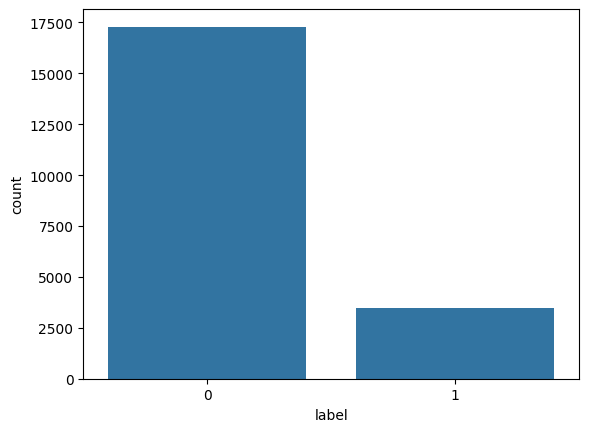

In [133]:
sns.countplot(x = 'label', data = df)

# Building Model

### Using deepmatcher

In [135]:
del df['id']

In [139]:
dm.data.split(df, data_dir, 'train.csv', 'valid.csv', 'test.csv',[3, 1, 1])

In [140]:
train, validation, test = dm.data.process(
    path=data_dir,
    cache='train_cache0.pth',
    train='train.csv',
    validation='valid.csv',
    test='test.csv',
    use_magellan_convention=True)

In [141]:
df.head()[['ltable_Full Name', 'rtable_Full Name', 'ltable_National Physician ID', 'rtable_National Physician ID', 'label']]

,ltable_Full Name,rtable_Full Name,ltable_National Physician ID,rtable_National Physician ID,label
218164,Andrew Warren,Dhiren Patel,1649689282,1619261062,0
128412,Annette Foerschler,Kristen Alexa Lee,NaN,NaN,0
347529,Nicky Miller,Ravikant M. Patil,NaN,NaN,0
227990,Ben Atchie,Daniel Abud,1134402415,NaN,0
319187,Maneesh Patel,Kimberly Weinstock,NaN,NaN,0


In [142]:
model = dm.MatchingModel(attr_summarizer='hybrid')
model.run_train(train, validation, epochs=3, batch_size=16, best_save_path=None, pos_neg_ratio=3)

/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


* Number of trainable parameters: 35333818
===>  TRAIN Epoch 1


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:939: UserWarning: Using non-full backward hooks on a Module that does not return a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_output. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not return a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/functional.py:2741: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Finished Epoch 1 || Run Time:  468.4 | Load Time:    2.9 || F1:  97.65 | Prec:  97.08 | Rec:  98.23 || Ex/s:  26.41

===>  EVAL Epoch 1
Finished Epoch 1 || Run Time:   38.8 | Load Time:    0.9 || F1:  99.70 | Prec: 100.00 | Rec:  99.41 || Ex/s: 104.54

* Best F1: 99.70282317979199
---------------------

===>  TRAIN Epoch 2


In [1]:
model.run_eval(test)

NameError: name 'model' is not defined

# Usecase

In [29]:
new_data_df = pd.read_csv("../data/test.csv")
new_data_df.head()

,ltable_Last Name,ltable_Status,ltable_National Physician ID,ltable_Full Name,ltable_Country,ltable_First Name,ltable_State/Region/Province,ltable_Specialty,ltable_Payment Currency,ltable_SAP Number,ltable_Payments Made To:,ltable_SAP Entity Name,ltable_HCP Category,ltable_Email Address,ltable_Contact Type,ltable_Quickbase Record ID#,rtable_Last Name,rtable_Status,rtable_National Physician ID,rtable_Full Name,rtable_Country,rtable_First Name,rtable_State/Region/Province,rtable_Specialty,rtable_Payment Currency,rtable_SAP Number,rtable_Payments Made To:,rtable_SAP Entity Name,rtable_HCP Category,rtable_Email Address,rtable_Contact Type,rtable_Quickbase Record ID#,label
0,Fraser,Active,NaN,Ashley Fraser,United States,Ashley,NaN,NaN,USD,NaN,NaN,NaN,Technician,Ashley.fraser@mylrh.org,HCP,2324.0,de Castro Afonso,Active,NaN,Luis Henrique de Castro Afonso,Brazil,Luis Henrique,Sao Paulo,Interventional Neuroradiology (INR),BRL,NaN,NaN,NaN,Physician,NaN,HCP,6047.0,0
1,el Hajjam,Active,NaN,Mostafa el Hajjam,France,Mostafa,NaN,Interventional Radiology (IR),EUR,90601338,Self,Mostafa El Hajjam,Physician,mostafa.elhajjam@aphp.fr,HCP,5591.0,el Hajjam,Active,NaN,Mostafa el Hajjam,France,Mostafa,NaN,Interventional Radiology (IR),EUR,90601338,Self,Mostafa El Hajjam,Physician,mostafa.elhajjam@aphp.fr,HCP,5591.0,1
2,Lewis,Active,NaN,Zachary Lewis,United States,Zachary,NaN,NaN,NaN,NaN,NaN,NaN,Technician,zachary.lewis@bswhealth.org,HCP,3164.0,Machi,Active,NaN,Paolo Machi,Switzerland,Paolo,NaN,NaN,EUR,NaN,NaN,NaN,Physician,NaN,HCP,775.0,0
3,Pietura,Active,NaN,Radoslaw Pietura,Poland,Radoslaw,NaN,NaN,EUR,NaN,NaN,NaN,Physician,radoslawpietura@poczta.onet.pl,HCP,3729.0,Caicedo,Active,NaN,Armando Jose Campo Caicedo,Colombia,Armando Jose Campo,NaN,Vascular Surgery (VS),USD,NaN,NaN,NaN,Physician,NaN,HCP,5947.0,0
4,Le Houerou,Active,NaN,Thomas Le Houerou,France,Thomas,NaN,Vascular Surgery (VS),EUR,90601189,Self,Thomas Le Houerou,Physician,thomas.lehouerou@yahoo.fr,HCP,6485.0,Le Houerou,Active,NaN,Thomas Le Houerou,France,Thomas,NaN,Vascular Surgery (VS),EUR,90601189,Self,Thomas Le Houerou,Physician,thomas.lehouerou@yahoo.fr,HCP,6485.0,1


In [30]:
new_data_df = new_data_df.reset_index(drop=True).reset_index().rename(columns = {"index": "_id"}).drop_duplicates()
new_data_df.to_csv("../data/new_data.csv", index=False)

In [47]:
candidate = dm.data.process_unlabeled(
    path=os.path.join('../', 'data', 'new_data.csv'),
    trained_model=model,
    ignore_columns=('ltable_id', 'rtable_id', 'label'))

In [48]:
predictions = model.run_prediction(candidate, output_attributes=list(candidate.get_raw_table().columns))
predictions = predictions.rename(columns={"match_score":"confident"})
threshold = 0.8
predictions['is_matched'] = np.where(predictions['confident'] > threshold, 1, 0)

===>  PREDICT Epoch 3


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-p

Finished Epoch 3 || Run Time:   28.5 | Load Time:    0.9 || F1:   0.00 | Prec:   0.00 | Rec:   0.00 || Ex/s:   0.00



In [50]:
predictions[['ltable_First Name', 'ltable_Last Name', 'rtable_First Name', 'rtable_Last Name', 'ltable_Full Name', 'rtable_Full Name',  'confident', 'is_matched']].head()

,ltable_First Name,ltable_Last Name,rtable_First Name,rtable_Last Name,ltable_Full Name,rtable_Full Name,confident,is_matched
_id,,,,,,,,
0,Ashley,Fraser,Luis Henrique,de Castro Afonso,Ashley Fraser,Luis Henrique de Castro Afonso,0.130752,0
1,Mostafa,el Hajja,Mostafa,el Hajjam,Mostafa el Hajjam,Mostafa el Hajjam,0.981638,1
2,Zachary,Lewis,Paolo,Machi,Zachary Lewis,Paolo Machi,0.136102,0
3,Radoslaw,Pietura,Armando Jose Campo,Caicedo,Radoslaw Pietura,Armando Jose Campo Caicedo,0.134011,0
4,Thomas,Le Houerou,Thomas,Le Houerou,Thomas Le Houerou,Thomas Le Houerou,0.981994,1


In [43]:
predictions.query("(is_matched == 1) ")[['ltable_First Name', 'ltable_Last Name', 'rtable_First Name', 'rtable_Last Name', 'ltable_Full Name', 'rtable_Full Name',  'confident', 'is_matched']].head(20)

,ltable_First Name,ltable_Last Name,rtable_First Name,rtable_Last Name,ltable_Full Name,rtable_Full Name,confident,is_matched
_id,,,,,,,,
1,Mostafa,el Hajjam,Mostafa,el Hajjam,Mostafa el Hajjam,Mostafa el Hajjam,0.982001,1
4,Thomas,Le Houerou,Thomas,Le Houerou,Thomas Le Houerou,Thomas Le Houerou,0.982120,1
6,Saleem,Husain,Saleem,Husain,Saleem Husain,Saleem Husain,0.982729,1
10,Roger,Alvarez,Roger,Alvarez,Roger Alvarez,Roger Alvarez,0.984103,1
16,Shawana,Hussain,Shawana,Hussain,Shawana Hussain,Shawana Hussain,0.982748,1
23,Hector Alfredo,Montenegro Rosales,Hector Alfredo,Montenegro Rosales,Hector Alfredo Montenegro Rosales,Hector Alfredo Montenegro Rosales,0.980793,1
25,Hiroyuki,Tajima,Hiroyuki,Tajima,Hiroyuki Tajima,Hiroyuki Tajima,0.982575,1
32,Ian,McCafferty,Ian,McCafferty,Ian McCafferty,Ian McCafferty,0.983410,1
33,Maurizio,Resta,Maurizio,Resta,Maurizio Resta,Maurizio Resta,0.982909,1


In [54]:
candidate = dm.data.process_unlabeled(
    path=os.path.join('../', 'data', 'new_data2.csv'),
    trained_model=model,
    ignore_columns=('ltable_id', 'rtable_id', 'label'))

In [55]:
predictions = model.run_prediction(candidate, output_attributes=list(candidate.get_raw_table().columns))
predictions = predictions.rename(columns={"match_score":"confident"})
threshold = 0.8
predictions['is_matched'] = np.where(predictions['confident'] > threshold, 1, 0)

===>  PREDICT Epoch 3


/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:949: UserWarning: Using non-full backward hooks on a Module that does not take as input a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not take as input a "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-packages/torch/nn/modules/module.py:974: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/Users/tu/SourceCode/envs/env_3.8.16/lib/python3.8/site-p

Finished Epoch 3 || Run Time:   29.4 | Load Time:    0.9 || F1:   0.00 | Prec:   0.00 | Rec:   0.00 || Ex/s:   0.00



In [57]:
predictions.query("(is_matched == 1) ")[['ltable_First Name', 'ltable_Last Name', 'rtable_First Name', 'rtable_Last Name', 'ltable_Full Name', 'rtable_Full Name',  'confident', 'is_matched']].head(20)

,ltable_First Name,ltable_Last Name,rtable_First Name,rtable_Last Name,ltable_Full Name,rtable_Full Name,confident,is_matched
_id,,,,,,,,
1,Mostafa,el Hajja,Mostafa,el Hajjam,Mostafa el Hajja,Mostafa el Hajjam,0.981267,1
4,Thomas,Le Houerou,Thomas,Le Houerou,Thomas Le Houerou,Thomas Le Houerou,0.981994,1
6,Salem,Husain,Saleem,Husain,Salem Husain,Saleem Husain,0.962436,1
10,Roger,Alvarez,Roger,Alvarez,Roger Alvarez,Roger Alvarez,0.984024,1
16,Shawana,Hussain,Shawana,Hussain,Shawana Hussain,Shawana Hussain,0.982657,1
23,Hector Alfredo,Montenegro Rosales,Hector Alfredo,Montenegro Rosales,Hector Alfredo Montenegro Rosales,Hector Alfredo Montenegro Rosales,0.980623,1
25,Hiroyuki,Tajima,Hiroyuki,Tajima,Hiroyuki Tajima,Hiroyuki Tajima,0.981998,1
32,Ian,McCafferty,Ian,McCafferty,Ian McCafferty,Ian McCafferty,0.983032,1
33,Maurizio,Resta,Maurizio,Resta,Maurizio Resta,Maurizio Resta,0.982348,1


## Using traditional ML approaches

In [ ]:
# Create a set of ML-matchers
dt = em.DTMatcher(name='DecisionTree', random_state=0)
svm = em.SVMMatcher(name='SVM', random_state=0)
rf = em.RFMatcher(name='RF', random_state=0)
lg = em.LogRegMatcher(name='LogReg', random_state=0)
ln = em.LinRegMatcher(name='LinReg')

In [ ]:
# Generate a set of features
F = em.get_features_for_matching(new_A, new_B, validate_inferred_attr_types=False)

In [ ]:
H = em.impute_table(F, 
                exclude_attrs=['_id', 'ltable_id', 'rtable_id', 'label'],
                strategy='mean')

In [ ]:
# Select the best ML matcher using CV
result = em.select_matcher([dt, rf, svm, ln, lg], table=H, 
        exclude_attrs=['_id', 'ltable_id', 'rtable_id', 'label'],
        k=5,
        target_attr='label', metric_to_select_matcher='f1', random_state=0)
result['cv_stats']